# TEM Tango Control — Client Tutorial

This notebook demonstrates how to connect to and interact with the TEM Tango devices.

All device servers must be running **before** executing this notebook.

Start the HAADF detector:

```bash
uv run python -m tango.test_context asyncroscopy.detectors.CAMERA.CAMERA --host 127.0.0.1 --port 8888
```


Start the Microscope (in a separate terminal):

```bash
uv run python -m tango.test_context asyncroscopy.ThermoMicroscope.ThermoMicroscope --host 127.0.0.1 --port 8889 \
  --prop "{'haadf_device_address': 'tango://127.0.0.1:8888/test/nodb/haadf#dbase=no'}"
```

---

If You Get “Address Already in Use”

It means something is already running on that port (likely from a previous session).

To check what is using a port:

```bash
lsof -i :8888
```

Then kill it using the PID shown:

```bash
kill -9 <PID>
```

Quick one-liner:

```bash
kill -9 $(lsof -t -i:8888)
```

Repeat for port `8889` if needed.

---

If a notebook crashes, `tango.test_context` may continue running in the background.
Always stop the previous process before restarting the device server.




## 1. Connect to devices

In [23]:
# !uv pip install trackpy

In [1]:
import json
import time
import numpy as np
import matplotlib.pyplot as plt
import tango
import pandas as pd
import trackpy as tp
import os

from scipy.ndimage import gaussian_filter
from skimage.feature import peak_local_max

# --nodb mode — use full tango:// URL with port and #dbase=no suffix
haadf_proxy = tango.DeviceProxy("tango://127.0.0.1:8888/test/nodb/haadf#dbase=no")
microscope_proxy = tango.DeviceProxy("tango://127.0.0.1:8889/test/nodb/thermomicroscope#dbase=no")

haadf_proxy.set_timeout_millis(120_000)
microscope_proxy.set_timeout_millis(120_000)

In [2]:
print('HAADF state     :', haadf_proxy.state())
print('Microscope state:', microscope_proxy.state())


HAADF state     : ON
Microscope state: ON


In [3]:
## helper funcs.
def get_image(dwell=10e-6, imsize=1024):
    haadf_proxy.dwell_time   = dwell
    haadf_proxy.image_width  = imsize
    haadf_proxy.image_height = imsize

    json_meta, raw_bytes = microscope_proxy.get_image('haadf')
    metadata  = dict(json.loads(json_meta))
    image = np.frombuffer(raw_bytes, dtype=metadata['dtype']).reshape(metadata['shape'])

    return image, metadata

In [4]:
im, meta = get_image(dwell=10e-6, imsize=512)


In [5]:
meta

{'detector': 'haadf',
 'shape': [512, 512],
 'dtype': 'uint16',
 'dwell_time': 1e-05,
 'timestamp': 1773320639.023941}

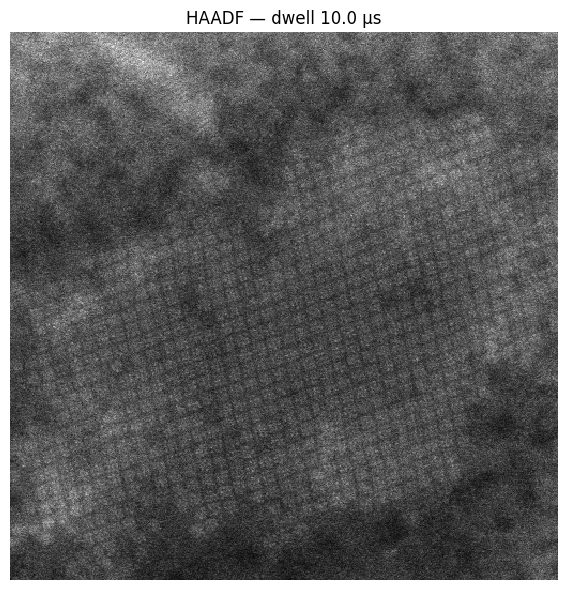

In [6]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(im, cmap='gray', interpolation='none')
ax.set_title(f"HAADF — dwell {meta['dwell_time']*1e6:.1f} µs")
ax.axis('off')
plt.tight_layout()
plt.show()

In [7]:
im.shape

(512, 512)

In [8]:
### benchmarking timing
beam_pos = np.array([0.5,0.5])

start = time.time()
microscope_proxy.place_beam(beam_pos)

end = time.time()
print("time to move:", end-start)


start = time.time()
microscope_proxy.blank_beam()

middle = time.time()
microscope_proxy.unblank_beam()

end = time.time()
print("time to blank:", middle-start)
print("time to unblank:", end-middle)

time to move: 0.023769855499267578
time to blank: 0.01978278160095215
time to unblank: 0.12267112731933594


### Now, we have all the ingredients we need to do atom blasting!

In [11]:
import sys
import torch
sys.path.insert(0,'/Users/austin/Documents/GitHub/Gomb-Net')
import GombNet
from GombNet.networks import Unet
from GombNet.utils import predict
from GombNet.data import *

from skimage.feature import blob_log
from pyTEMlib.atom_tools import atom_refine

def detect_blobs_unet():
    # Load pretrained model
    model = Unet(1, 1, [64, 128, 256, 512, 1024], dropout = 0.25)
    checkpoint = torch.load('../../big_movie/Unet_pretrained_best.pth')
    model.load_state_dict(checkpoint['model_state_dict'])
    print('Loaded model')

    device = 'mps'
    model = model.to(device)
    model.eval()

    all_predictions = []
    for i in range(data_np.shape[0]):
        img = data_np[i]
        tiles, coords = tile_image(img, tile_size=256, overlap=64)
        tiles_t = torch.from_numpy(tiles[:, None]).float().to(device)

        with torch.no_grad():
            preds = model(tiles_t).cpu().numpy()[:, 0]

        stitched = stitch_image(preds,coords,image_shape=img.shape,tile_size=256)
        stitched = gaussian_filter(stitched, sigma=1)
        all_predictions.append(stitched)
    all_predictions = np.array(all_predictions)

    blobs = blob_log(all_predictions, min_sigma=1, max_sigma=10, threshold=0.05)
    sym = atom_refine(np.array(im), blobs, 6, max_int = 0, min_int = 0, max_dist = 1)
    pos = np.array(sym['atoms'])

    return pos



ModuleNotFoundError: No module named 'torch'

In [17]:
def detect_blobs(im):
    p99 = np.percentile(im.ravel(), 99)
    im = np.clip(im, 0, p99)
    smoothed = gaussian_filter(im, sigma=2)
    smoothed -= smoothed.min()
    smoothed /= smoothed.max()
    blobs = peak_local_max(smoothed, min_distance=6, threshold_abs=0.3)
    return blobs


# def blast_coordinates_from_id(id, linked, imsize):
#     # check if the id is still here:
#     if id not in linked['particle'].values:
#         TARGET_PRESENT = False
#     current_frame = linked[linked['particle'] == id]['frame'].max()
#     current_x = linked[linked['particle'] == id][linked['frame'] == current_frame]['x'].values[0]
#     current_y = linked[linked['particle'] == id][linked['frame'] == current_frame]['y'].values[0]
#     # normalize to [0:1]
#     current_x_norm = current_x / imsize
#     current_y_norm = current_y / imsize
#     return current_x_norm, current_y_norm


def blast_coordinates_from_id(id, linked, imsize):
    particle_rows = linked[linked['particle'] == id]
    
    if particle_rows.empty:
        return None, None
    
    current_frame = particle_rows['frame'].max()
    
    # ── fix: single combined mask with .loc ──────────────────────────────────
    mask = (linked['particle'] == id) & (linked['frame'] == current_frame)
    row  = linked.loc[mask]
    
    if row.empty:
        return None, None
    
    current_x = row['x'].values[0]
    current_y = row['y'].values[0]
    
    # normalise to [0, 1]
    norm_x = current_x / imsize
    norm_y = current_y / imsize
    
    return norm_x, norm_y

In [18]:
# pre_frames = 5
# imsize = 512
# dwell = 8e-6
# 
# # get pre-frames to test drift and acquire target
# image_array = np.zeros((pre_frames, imsize, imsize))
# for frame in range(pre_frames):
#     im, meta = get_image(dwell=dwell, imsize=imsize)
#     image_array[frame,:,:] = im
# 
# # get blobs
# blobs_list = []
# for i, im in enumerate(image_array):
#     blobs = detect_blobs(im)
#     blobs_list.append(blobs)
# 
# # track atoms
# records = []
# for i, features in enumerate(blobs_list):
#     for (x, y) in features:
#         records.append({'x': x, 'y': y, 'frame': i})
# df_pre = pd.DataFrame(records)
# 
# # link with trackpy
# search_range = 10
# memory = 3
# linked = tp.link_df(df_pre, search_range=search_range, memory=memory)
# linked = tp.filter_stubs(linked, 4) # keep only particles in > n frames
# linked = linked.reset_index(drop=True)
# 
# # calculate drift
# drift = tp.compute_drift(linked)
# print(drift)
# 
# # select target near center
# target_xy = (imsize//2, imsize//2)
# frame0 = linked[linked['frame'] == 0]
# distances = np.sqrt((frame0['x'] - target_xy[0])**2 + (frame0['y'] - target_xy[1])**2)
# closest_index = distances.idxmin()
# target_particle_id = frame0.loc[closest_index, 'particle']
# 
# # now, do the blasting
# TARGET_PRESENT = True
# 
# while TARGET_PRESENT:
#     im, meta = get_image(dwell=10e-6, imsize=imsize)
#     image_array = np.concatenate([image_array[1:,:,:], im[None,:,:]], axis=0)
#     blobs = detect_blobs(im)
#     df_live = pd.DataFrame({'x': blobs[:,0], 'y': blobs[:,1]})
#     df_live['frame'] = linked['frame'].max() + 1
#     linked = pd.concat([linked, df_live], ignore_index=True)
#     linked = tp.link_df(linked, search_range=search_range, memory=memory)
# 
#     # get target id
#     target_x, target_y = blast_coordinates_from_id(target_particle_id, linked, imsize)
#     
#     # move andf blast
#     microscope_proxy.place_beam((target_x, target_y))
#     microscope_proxy.unblank_beam()
#     time.sleep(0.5)
#     microscope_proxy.blank_beam()
#     print(f'blast iter {linked['frame'].max()} ')
# 
# 
# # now save the images, the linked dataframe, and the target id
# 
# # also, visualize through the loop

In [21]:
# ── blasting loop ─────────────────────────────────────────────────────────────
blast_frame    = int(linked['frame'].max()) + 1
TARGET_PRESENT = True

# store target's last known pixel position for fallback matching
target_last = linked[linked['particle'] == target_particle_id].iloc[-1]
target_last_xy = (target_last['x'], target_last['y'])

while TARGET_PRESENT:

    # acquire new frame
    im, meta = get_image(dwell=10e-6, imsize=imsize)
    image_array = np.concatenate([image_array[1:, :, :], im[None, :, :]], axis=0)

    # detect blobs
    blobs   = detect_blobs(im)
    df_live = pd.DataFrame({'x': blobs[:, 0],
                            'y': blobs[:, 1],
                            'frame': blast_frame})

    # ── only link recent tail + new frame, not full history ──────────────────
    tail_frames = linked[linked['frame'] >= blast_frame - memory - 1].copy()
    to_link     = pd.concat([tail_frames, df_live], ignore_index=True)
    to_link     = tp.link_df(to_link, search_range=search_range, memory=memory)

    # extract just the new frame's rows with their assigned particle IDs
    new_rows           = to_link[to_link['frame'] == blast_frame].copy()
    new_rows['particle'] = new_rows['particle'] + linked['particle'].max() * 0  # IDs already consistent within tail
    linked             = pd.concat([linked, new_rows], ignore_index=True)

    # ── re-identify target: find which particle ID is closest to last known pos
    if new_rows.empty:
        print(f"No blobs detected in frame {blast_frame} — stopping.")
        TARGET_PRESENT = False
        break

    # check if target particle ID survived into new frame
    if target_particle_id in new_rows['particle'].values:
        # update last known position
        row = new_rows[new_rows['particle'] == target_particle_id].iloc[0]
        target_last_xy = (row['x'], row['y'])
    else:
        # ID was lost — find nearest blob to last known position
        dists = np.sqrt((new_rows['x'] - target_last_xy[0])**2 +
                        (new_rows['y'] - target_last_xy[1])**2)
        nearest_idx        = dists.idxmin()
        nearest_row        = new_rows.loc[nearest_idx]

        if dists[nearest_idx] > search_range:
            print(f"Target moved too far (>{search_range}px) — stopping.")
            TARGET_PRESENT = False
            break

        # re-adopt the new particle ID
        target_particle_id = nearest_row['particle']
        target_last_xy     = (nearest_row['x'], nearest_row['y'])
        print(f"  ↳ Target re-identified as particle {target_particle_id}")

    target_x, target_y = target_last_xy

    # normalise for beam placement
    norm_x = target_x / imsize
    norm_y = target_y / imsize

    microscope_proxy.place_beam((norm_x, norm_y))
    microscope_proxy.unblank_beam()
    time.sleep(0.5)
    microscope_proxy.blank_beam()

    print(f"Blast iter {blast_frame}  |  target @ ({target_x:.1f}, {target_y:.1f})")

    # ── save ──────────────────────────────────────────────────────────────────
    np.save(f"frames/image_array_{blast_frame:04d}.npy", image_array)
    linked.to_csv("linked_trajectories.csv", index=False)

    # ── visualise ─────────────────────────────────────────────────────────────
    ax.clear()
    ax.imshow(im, cmap='gray', origin='upper', vmin=np.percentile(im, 1),
                                               vmax=np.percentile(im, 99))
    ax.scatter(blobs[:, 1], blobs[:, 0],
               s=30, c='cyan', marker='x', linewidths=1, label='blobs')
    ax.scatter(target_y, target_x,
               s=120, facecolors='none', edgecolors='red',
               linewidths=2, label='target')
    ax.set_title(f"Frame {blast_frame}  |  particle {target_particle_id}")
    ax.legend(loc='upper right', fontsize=8)
    fig.tight_layout()
    plt.pause(0.05)

    blast_frame += 1

Frame 18: 637 trajectories present.
Blast iter 18  |  target @ (221.0, 278.0)


KeyboardInterrupt: 

In [22]:
# ── blasting loop ─────────────────────────────────────────────────────────────
blast_frame    = int(linked['frame'].max()) + 1
TARGET_PRESENT = True

# seed target position from pre-frame linking
target_row     = linked[linked['particle'] == target_particle_id].iloc[-1]
target_last_xy = np.array([target_row['x'], target_row['y']])

while TARGET_PRESENT:

    # acquire new frame
    im, meta = get_image(dwell=10e-6, imsize=imsize)
    image_array = np.concatenate([image_array[1:, :, :], im[None, :, :]], axis=0)

    # detect blobs
    blobs   = detect_blobs(im)

    if len(blobs) == 0:
        print("No blobs detected — stopping.")
        TARGET_PRESENT = False
        break

    df_live = pd.DataFrame({'x': blobs[:, 0], 'y': blobs[:, 1], 'frame': blast_frame})

    # ── trackpy: link tail only, compute drift, drift-correct target pos ──────
    tail    = linked[linked['frame'] >= blast_frame - memory - 1].copy()
    to_link = pd.concat([tail, df_live], ignore_index=True)
    to_link = tp.link_df(to_link, search_range=search_range, memory=memory)

    try:
        drift        = tp.compute_drift(to_link)
        frame_drift  = drift.loc[blast_frame]                 # dx, dy for this frame
        drift_xy     = np.array([frame_drift['x'], frame_drift['y']])
    except (KeyError, Exception):
        drift_xy = np.array([0.0, 0.0])                       # no drift estimate yet

    # drift-corrected target position
    target_corrected_xy = target_last_xy + drift_xy

    # ── nearest blob to drift-corrected position ──────────────────────────────
    dists     = np.linalg.norm(blobs - target_corrected_xy, axis=1)
    nearest_i = np.argmin(dists)
    min_dist  = dists[nearest_i]

    if min_dist > search_range:
        print(f"Nearest blob is {min_dist:.1f}px away after drift correction — target lost, stopping.")
        TARGET_PRESENT = False
        break

    target_last_xy = blobs[nearest_i]     # update to actual blob position
    target_x, target_y = target_last_xy

    # append only new rows to linked for future drift computation
    new_rows = to_link[to_link['frame'] == blast_frame].copy()
    linked   = pd.concat([linked, new_rows], ignore_index=True)

    # blast
    microscope_proxy.place_beam((target_x / imsize, target_y / imsize))
    microscope_proxy.unblank_beam()
    time.sleep(0.5)
    microscope_proxy.blank_beam()

    print(f"Blast iter {blast_frame}  |  target @ ({target_x:.1f}, {target_y:.1f})"
          f"  |  drift: ({drift_xy[0]:+.1f}, {drift_xy[1]:+.1f})  |  snap dist: {min_dist:.1f}px")

    # ── save ──────────────────────────────────────────────────────────────────
    np.save(f"frames/image_array_{blast_frame:04d}.npy", image_array)
    linked.to_csv("linked_trajectories.csv", index=False)

    # ── visualise ─────────────────────────────────────────────────────────────
    ax.clear()
    ax.imshow(im, cmap='gray', origin='upper',
              vmin=np.percentile(im, 1), vmax=np.percentile(im, 99))
    ax.scatter(blobs[:, 1], blobs[:, 0],
               s=30, c='cyan', marker='x', linewidths=1, label='blobs')
    ax.scatter(target_corrected_xy[1], target_corrected_xy[0],
               s=80, c='yellow', marker='+', linewidths=2, label='drift-corrected prediction')
    ax.scatter(target_y, target_x,
               s=120, facecolors='none', edgecolors='red',
               linewidths=2, label='target (snapped)')
    ax.set_title(f"Frame {blast_frame}  |  drift: ({drift_xy[0]:+.1f}, {drift_xy[1]:+.1f})")
    ax.legend(loc='upper right', fontsize=8)
    fig.tight_layout()
    plt.pause(0.05)

    blast_frame += 1

plt.ioff()
plt.show()
print("Blasting loop complete.")

Frame 44: 634 trajectories present.
Blast iter 44  |  target @ (209.0, 228.0)  |  drift: (-1.6, -1.3)  |  snap dist: 4.7px


KeyboardInterrupt: 